NAME: ALOK KUMAR MAVI

SECTION: B

ROLL.NO.: 05

CU ID: CU240251681

LAB SHEET - 03

=== Descriptive Statistics ===
            income     price         age     rooms
mean      3.870671  2.068558   28.639486  5.429000
median    3.534800  1.797000   29.000000  5.229129
mode      3.125000  5.000010   52.000000  5.000000
variance  3.609323  1.331615  158.396260  6.121533
std_dev   1.899822  1.153956   12.585558  2.474173


Pearson Correlation Coefficient (Income vs Price): 0.6881
P-value: 0.0000e+00



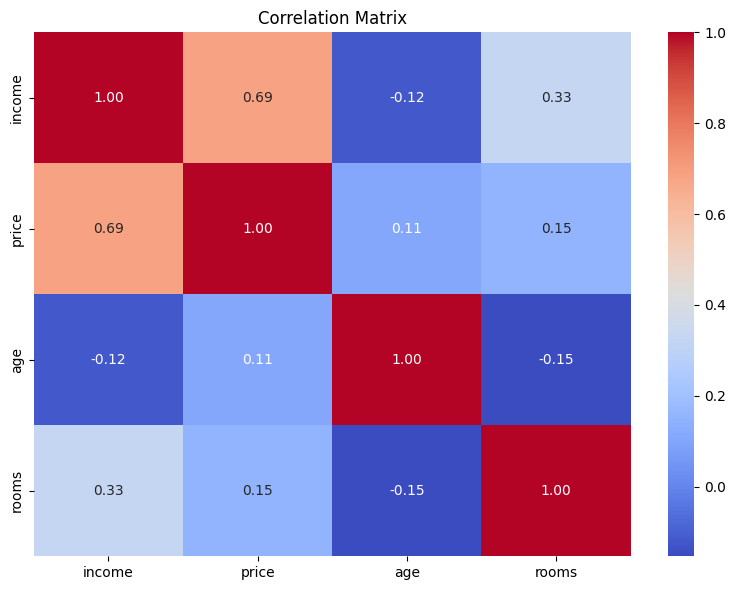

=== Independent Sample t-test ===
T-statistic: -11.8104
P-value: 4.8935e-32
Decision: Reject H0. Significant difference in mean prices between newer and older houses.


=== One-Way ANOVA ===
F-statistic: 71.5465
P-value: 1.0839e-31
Decision: Reject H0. Significant house price differences exist across age groups.


=== Linear Regression Summary ===
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.473
Model:                            OLS   Adj. R-squared:                  0.473
Method:                 Least Squares   F-statistic:                 1.856e+04
Date:                Mon, 07 Sep 2026   Prob (F-statistic):               0.00
Time:                        04:42:00   Log-Likelihood:                -25623.
No. Observations:               20640   AIC:                         5.125e+04
Df Residuals:                   20638   BIC:                         5.127e+04
Df Model:         

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.datasets import fetch_california_housing

# Step 1: Load Dataset (California Housing Dataset)
raw_data = fetch_california_housing(as_frame=True)
dataset = raw_data.frame

# Rename columns for clarity (MedInc: Income in $10k, MedHouseVal: Price in $100k)
dataset = dataset.rename(columns={'MedInc': 'income', 'MedHouseVal': 'price', 'HouseAge': 'age', 'AveRooms': 'rooms'})

# Step 3: Descriptive Statistics
numerical_cols = ['income', 'price', 'age', 'rooms']

def compute_descriptive_stats(df, columns):
    metrics = {}
    for col in columns:
        valid_series = df[col].dropna()
        metrics[col] = {
            'mean': valid_series.mean(),
            'median': valid_series.median(),
            'mode': valid_series.mode()[0],
            'variance': valid_series.var(),
            'std_dev': valid_series.std()
        }
    return pd.DataFrame(metrics)

descriptive_summary = compute_descriptive_stats(dataset, numerical_cols)
print("=== Descriptive Statistics ===")
print(descriptive_summary)
print("\n" + "="*50 + "\n")

# Step 4: Correlation Analysis (Income vs Price)
cleaned_data = dataset[['income', 'price']].dropna()
pearson_corr, correlation_p_value = stats.pearsonr(cleaned_data['income'], cleaned_data['price'])

print(f"Pearson Correlation Coefficient (Income vs Price): {pearson_corr:.4f}")
print(f"P-value: {correlation_p_value:.4e}\n")

plt.figure(figsize=(8, 6))
sns.heatmap(dataset[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# Step 5 & 6: Independent Sample t-test
# Compare house prices between Newer Houses (age <= 20) and Older Houses (age > 20)
# H0: Mean house price is equal between newer and older houses.
# H1: Mean house price differs significantly between newer and older houses.
newer_houses = dataset[dataset['age'] <= 20]['price'].dropna()
older_houses = dataset[dataset['age'] > 20]['price'].dropna()

ttest_stat, ttest_p_value = stats.ttest_ind(newer_houses, older_houses, equal_var=False)

print("=== Independent Sample t-test ===")
print(f"T-statistic: {ttest_stat:.4f}")
print(f"P-value: {ttest_p_value:.4e}")
if ttest_p_value < 0.05:
    print("Decision: Reject H0. Significant difference in mean prices between newer and older houses.")
else:
    print("Decision: Fail to reject H0. No significant price difference detected based on age category.")
print("\n" + "="*50 + "\n")

# Step 7: One-Way ANOVA
# Create house age categories: New (<=15), Medium (16-35), Old (>35)
dataset['age_group'] = pd.cut(dataset['age'], bins=[0, 15, 35, 100], labels=['New', 'Medium', 'Old'])

# H0: Mean house prices across the three age groups are equal.
# H1: At least one age group has a different mean house price.
group_new = dataset[dataset['age_group'] == 'New']['price'].dropna()
group_medium = dataset[dataset['age_group'] == 'Medium']['price'].dropna()
group_old = dataset[dataset['age_group'] == 'Old']['price'].dropna()

f_stat, anova_p_value = stats.f_oneway(group_new, group_medium, group_old)

print("=== One-Way ANOVA ===")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {anova_p_value:.4e}")
if anova_p_value < 0.05:
    print("Decision: Reject H0. Significant house price differences exist across age groups.")
else:
    print("Decision: Fail to reject H0. No significant price differences across age groups.")
print("\n" + "="*50 + "\n")

# Step 8 & 9: Simple Linear Regression
# Predict House Price based on Median Income
regression_data = dataset[['income', 'price']].dropna()
regression_model = smf.ols('price ~ income', data=regression_data).fit()

print("=== Linear Regression Summary ===")
print(regression_model.summary())

NAME: ALOK KUMAR MAVI

SECTION: B

ROLL.NO.: 05

CU ID: CU240251681

LAB SHEET - 03

### Questions and Answers

**1. What is the difference between descriptive statistics and inferential statistics?**

* **Descriptive Statistics:** Summarize, organize, and present dataset characteristics using measures such as mean, median, standard deviation, and variance without attempting to draw conclusions beyond the observed sample.
* **Inferential Statistics:** Use sample data to draw inferences, make estimates, test hypotheses, and generalize patterns to a larger population under uncertainty.

**2. Explain the concepts of the Null Hypothesis ($H_0$) and Alternative Hypothesis ($H_1$).**

* **Null Hypothesis ($H_0$):** The default assumption stating that there is no effect, no statistically significant relationship, or no difference between target variables or groups.
* **Alternative Hypothesis ($H_1$):** The claim being tested that contradicts $H_0$, asserting that an effect, relationship, or systematic difference exists.

**3. What is a p-value? How is it used to make statistical decisions?**

* **Definition:** The p-value measures the probability of obtaining test results at least as extreme as the observed sample outcome, assuming $H_0$ is true.
* **Decision Rule:**
* If $p \le \alpha$ (typically $0.05$), reject $H_0$ (statistically significant result).
* If $p > \alpha$, fail to reject $H_0$ (insufficient evidence to support an effect).



**4. Differentiate between a t-test and ANOVA. In which situations is each test applied?**

* **Independent Sample t-test:** Compares the sample means of **two** independent groups (e.g., comparing prices between newer vs. older homes).
* **One-Way ANOVA:** Compares sample means across **three or more** independent groups simultaneously (e.g., comparing house prices across low-, middle-, and high-income neighborhoods) to prevent Type I error inflation.

**5. What does the Pearson correlation coefficient indicate? What are its possible values?**

* **Definition:** Measures the strength and direction of a linear relationship between two continuous variables.
* **Range:** Ranges strictly from $-1$ to $+1$:
* $+1$: Perfect positive linear relationship.
* $0$: No linear relationship.
* $-1$: Perfect negative linear relationship.



**6. Explain the significance of $R^2$ (Coefficient of Determination) in Linear Regression.**

* **Definition:** Quantifies the proportion of total variance in the dependent variable explained by the independent variable(s) in the regression model.
* **Interpretation:** An $R^2 = 0.65$ indicates that $65\%$ of the variability in house prices is accounted for by median neighborhood income.

**7. Why is statistical analysis important before applying machine learning algorithms?**

* Identifies data skewness, missing value patterns, outliers, and multicollinearity.
* Validates key structural assumptions (e.g., linearity, normality).
* Guides feature selection and data preprocessing transformation strategies to avoid model overfitting and bias.

**8. What assumptions should be satisfied before performing a t-test or ANOVA?**

* **Scale of Measurement:** The dependent variable must be continuous (interval or ratio).
* **Independence:** Observations across and within groups must be independent.
* **Normality:** Target variables within each group should follow an approximately normal distribution.
* **Homogeneity of Variance:** Variances across evaluated groups should be approximately equal (homoscedasticity).

**9. How can regression analysis help organizations in forecasting and decision-making?**

* **Quantifying Driver Impact:** Evaluates how changes in input variables (e.g., square footage, income tiers) mathematically impact target metrics (e.g., property evaluation).
* **Forecasting:** Generates baseline target predictions for prospective investments or business planning scenarios.
* **Scenario Testing:** Enables "what-if" risk simulations based on estimated regression coefficients and confidence bounds.

**10. Give two real-world applications where hypothesis testing is commonly used in data analytics.**

* **E-Commerce A/B Testing:** Determining whether a revised checkout interface design produces a statistically significant increase in user conversion rate compared to the baseline design.
* **Real Estate Pricing Strategy:** Evaluating whether properties located near public transit hubs command a statistically higher price per square foot than properties located further away.